In [1]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/diagnosis-of-diabetic-retinopathy")

print("Path to dataset files:", path)

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/6a/26/848411b6bef16d21d5132669cde3ff1ec018ebae601ea733a8d4a093a40e/kagglehub-0.4.1-py3-none-any.whl.metadata
  Obtaining dependency information for kagglesdk<1.0,>=0.1.14 from https://files.pythonhosted.org/packages/1c/d8/71a8b9115ed2cf8b487c8976e66678311e82c73980e103eda15623abd6a5/kagglesdk-0.1.15-py3-none-any.whl.metadata
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/d0/30/dc54f88dd4a2b5dc8a0279bdd7270e735851848b762aeb1c1184ed1f6b14/tqdm-4.67.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] 

100%|██████████| 30.1M/30.1M [00:01<00:00, 22.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pkdarabi/diagnosis-of-diabetic-retinopathy/versions/2


In [14]:
!pip install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
main_path = '/root/.cache/kagglehub/datasets/pkdarabi/diagnosis-of-diabetic-retinopathy/versions/2/Diagnosis of Diabetic Retinopathy/train'
categories = ["DR", "No_DR"]

In [5]:
import os
import pandas as pd

image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(main_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)  

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

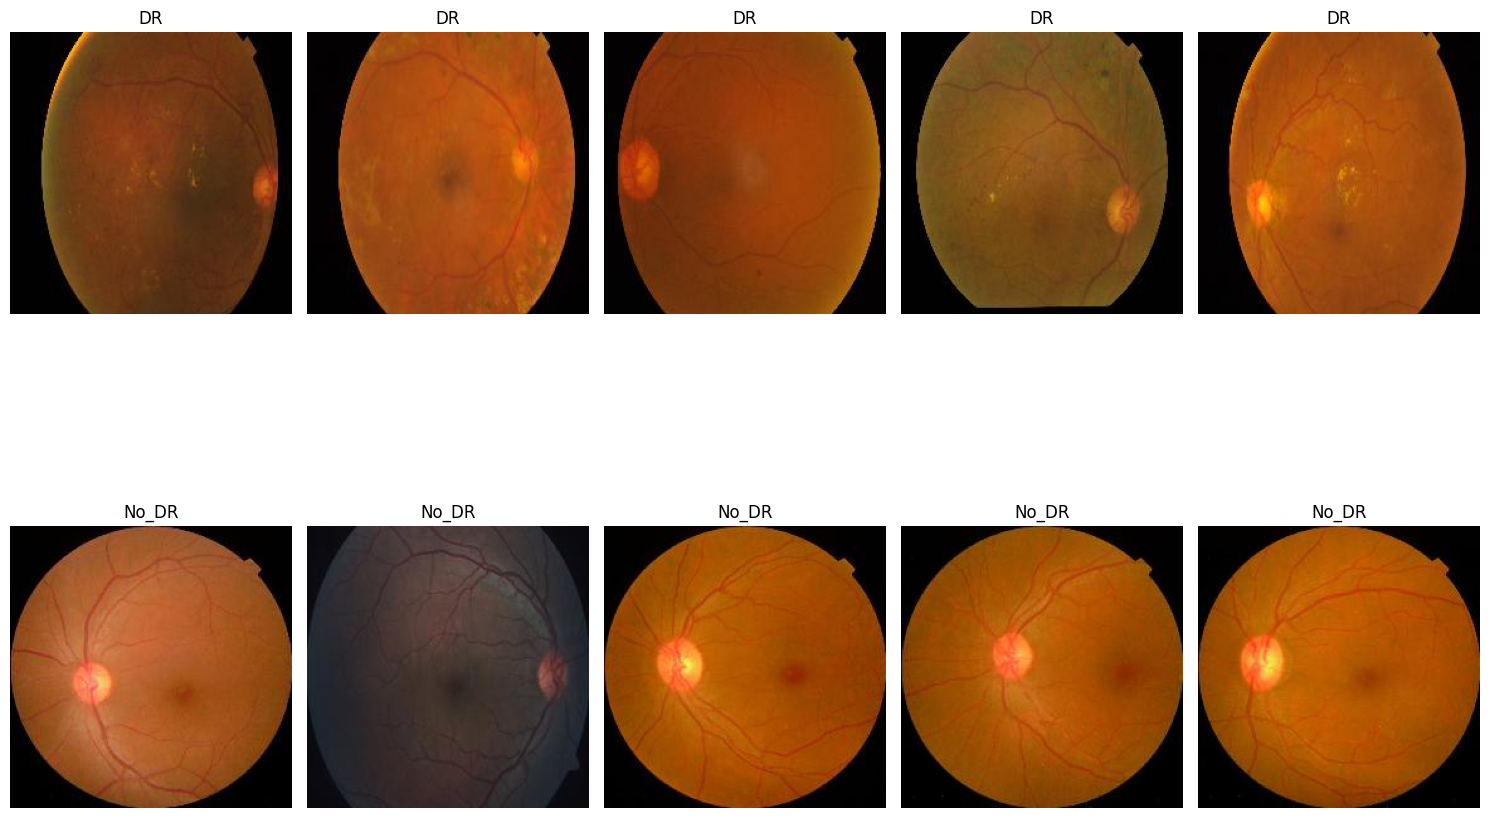

In [6]:
import cv2
import matplotlib.pyplot as plt

num_images = 5

plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df['label'] == category]['image_path'].iloc[:num_images]

    for j, img_path in enumerate(category_images):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)

plt.tight_layout()
plt.show()

In [21]:
!pip install imblearn

  Obtaining dependency information for imblearn from https://files.pythonhosted.org/packages/81/a7/4179e6ebfd654bd0eac0b9c06125b8b4c96a9d0a8ff9e9507eb2a26d2d7e/imblearn-0.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/c7/b5/56f1ceb568676c0231d12b2fed17ebfd606dd1f627e7372aaed5dd56bd97/imbalanced_learn-0.14.1-py3-none-any.whl.metadata
  Obtaining dependency information for sklearn-compat<0.2,>=0.1.5 from https://files.pythonhosted.org/packages/53/60/08cb1b41563a0a8f26a72b8c5d1726986ab535fee67aa95541b2a2cc1dfa/sklearn_compat-0.1.5-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 8.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['category_encoded'] = label_encoder.fit_transform(df['label'])

In [8]:
df = df[['image_path', 'category_encoded']]

In [9]:
from imblearn.over_sampling import RandomOverSampler

In [10]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['image_path']], df['category_encoded'])

In [11]:
df_resampled = pd.DataFrame(X_resampled, columns=['image_path'])
df_resampled['category_encoded'] = y_resampled

In [12]:
print("\nClass distribution after oversampling:")
print(df_resampled['category_encoded'].value_counts())


Class distribution after oversampling:
category_encoded
0    1050
1    1050
Name: count, dtype: int64


In [13]:
df_resampled

,image_path,category_encoded
0,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
1,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
2,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
3,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
4,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
...,...,...
2095,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1
2096,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1
2097,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1
2098,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1


In [14]:
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [38]:
!pip install segmentation-models

  Obtaining dependency information for segmentation-models from https://files.pythonhosted.org/packages/da/b9/4a183518c21689a56b834eaaa45cad242d9ec09a4360b5b10139f23c63f4/segmentation_models-1.0.1-py3-none-any.whl.metadata
  Obtaining dependency information for keras-applications<=1.0.8,>=1.0.7 from https://files.pythonhosted.org/packages/71/e3/19762fdfc62877ae9102edf6342d71b28fbfd9dea3d2f96a882ce099b03f/Keras_Applications-1.0.8-py3-none-any.whl.metadata
  Obtaining dependency information for image-classifiers==1.0.0 from https://files.pythonhosted.org/packages/81/98/6f84720e299a4942ab80df5f76ab97b7828b24d1de5e9b2cbbe6073228b7/image_classifiers-1.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for efficientnet==1.0.0 from https://files.pythonhosted.org/packages/97/82/f3ae07316f0461417dc54affab6e86ab188a5a22f33176d35271628b96e0/efficientnet-1.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for scikit-image from https://files.pythonhosted.org/packages/a5

In [15]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)


train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,  
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']  
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,  
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded'] 
)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
img_size = (224, 224)
channels = 3  
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)  
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',  
    y_col='category_encoded',     
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path', 
    y_col='category_encoded',    
    target_size=img_size,
    class_mode='binary',  
    color_mode='rgb', 
    shuffle=False,  
    batch_size=batch_size
)

Found 1680 validated image filenames belonging to 2 classes.
Found 210 validated image filenames belonging to 2 classes.
Found 210 validated image filenames belonging to 2 classes.


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [19]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, GaussianNoise, 
                                     Input, MultiHeadAttention, Reshape)
from tensorflow.keras.optimizers import Adam

def create_vgg16_model(input_shape):
    inputs = Input(shape=input_shape)
    
    base_model = VGG16(weights='imagenet', input_tensor=inputs, include_top=False)
    
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    height, width, channels = 7, 7, 512  
    x = Reshape((height * width, channels))(x)
    
    attention_output = MultiHeadAttention(num_heads=8, key_dim=channels)(x, x)
    attention_output = Reshape((height, width, channels))(attention_output)
    
    x = GaussianNoise(0.25)(attention_output)
    
    x = GlobalAveragePooling2D()(x)
    
    x = Dense(512, activation='relu')(x)
    x = GaussianNoise(0.25)(x)  
    x = Dropout(0.25)(x)  
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)

    return model

input_shape = (224, 224, 3)

cnn_model = create_vgg16_model(input_shape)

cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [20]:

history = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=5,  
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/5


2026-01-22 20:31:07.904604: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8905
2026-01-22 20:31:11.207501: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-01-22 20:31:11.212880: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:231] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-01-22 20:31:11.212899: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:234] Used ptxas at /usr/local/cuda-11.8/bin/ptxas
2026-01-22 20:31:11.213006: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:322] UNIMPLEMENTED: /usr/local/cuda-11.8/bin/ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2026-01-22 20:31:56.986281: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot 

105/105 [==============================] - 88s 103ms/step - loss: 0.4079 - accuracy: 0.8030 - val_loss: 0.2051 - val_accuracy: 0.9190
Epoch 2/5
105/105 [==============================] - 2s 20ms/step - loss: 0.2307 - accuracy: 0.9161 - val_loss: 0.1924 - val_accuracy: 0.9333
Epoch 3/5
105/105 [==============================] - 2s 18ms/step - loss: 0.2234 - accuracy: 0.9190 - val_loss: 0.1671 - val_accuracy: 0.9238
Epoch 4/5
105/105 [==============================] - 2s 18ms/step - loss: 0.2090 - accuracy: 0.9280 - val_loss: 0.1670 - val_accuracy: 0.9286
Epoch 5/5
105/105 [==============================] - 2s 17ms/step - loss: 0.1854 - accuracy: 0.9345 - val_loss: 0.1488 - val_accuracy: 0.9381


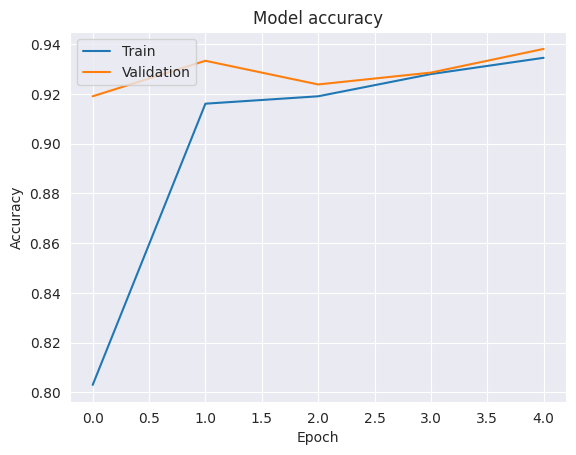

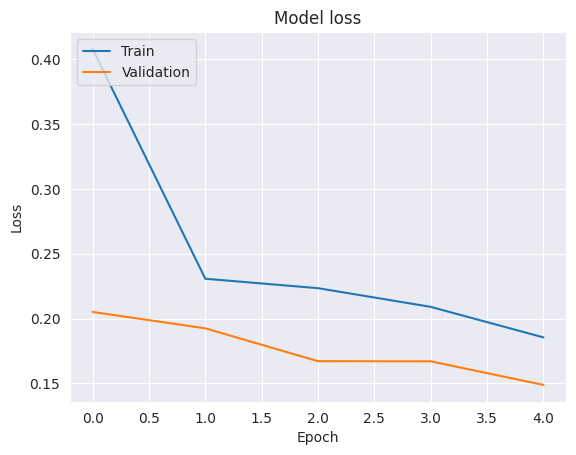

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [23]:
test_labels = test_gen_new.classes  
predictions = cnn_model.predict(test_gen_new)  
predicted_labels = (predictions > 0.5).astype(int).flatten()

14/14 [==============================] - 0s 15ms/step


In [24]:
from sklearn.metrics import classification_report

report = classification_report(test_labels, predicted_labels, target_names=list(test_gen_new.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           0       0.99      0.87      0.92       105
           1       0.88      0.99      0.93       105

    accuracy                           0.93       210
   macro avg       0.94      0.93      0.93       210
weighted avg       0.94      0.93      0.93       210



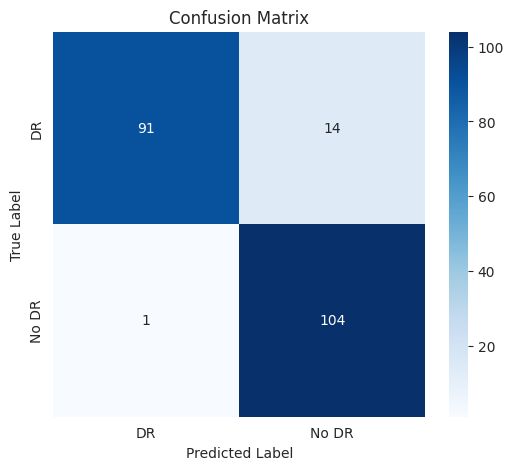

In [25]:
conf_matrix = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DR', 'No DR'], yticklabels=['DR', 'No DR'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, GaussianNoise, 
                                     Input, MultiHeadAttention, Reshape)
from tensorflow.keras.optimizers import Adam

def create_lightweight_model(input_shape):
    inputs = Input(shape=input_shape)
    base_model = MobileNetV2(weights='imagenet', input_tensor=inputs, include_top=False)
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    height, width, channels = x.shape[1], x.shape[2], x.shape[3]
    x = Reshape((height * width, channels))(x)
    attention_output = MultiHeadAttention(num_heads=4, key_dim=channels)(x, x)
    attention_output = Reshape((height, width, channels))(attention_output)
    x = GaussianNoise(0.2)(attention_output)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = GaussianNoise(0.2)(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (224, 224, 3)
cnn_model = create_lightweight_model(input_shape)
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

9406464/9406464 [==============================] - 0s 0us/step


In [27]:
history = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=5,  
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
105/105 [==============================] - 35s 24ms/step - loss: 0.2244 - accuracy: 0.9232 - val_loss: 0.1435 - val_accuracy: 0.9619
Epoch 2/5
105/105 [==============================] - 2s 16ms/step - loss: 0.1487 - accuracy: 0.9554 - val_loss: 0.1765 - val_accuracy: 0.9238
Epoch 3/5
105/105 [==============================] - 2s 17ms/step - loss: 0.1160 - accuracy: 0.9619 - val_loss: 0.1069 - val_accuracy: 0.9714
Epoch 4/5
105/105 [==============================] - 2s 18ms/step - loss: 0.0975 - accuracy: 0.9726 - val_loss: 0.0948 - val_accuracy: 0.9714
Epoch 5/5
105/105 [==============================] - 2s 18ms/step - loss: 0.0674 - accuracy: 0.9798 - val_loss: 0.1219 - val_accuracy: 0.9524


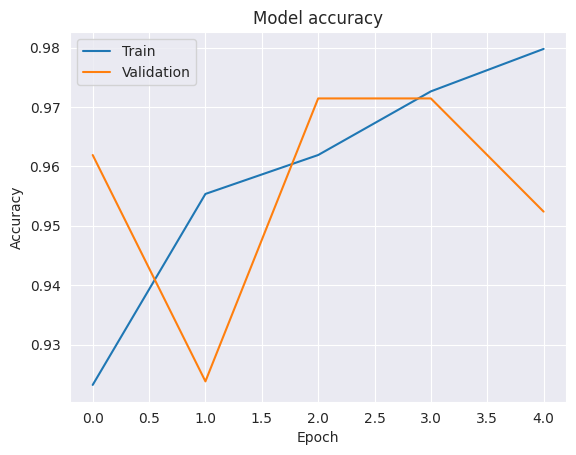

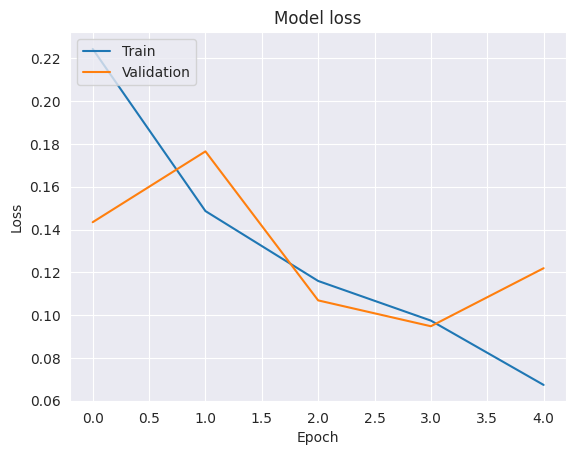

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [29]:
from sklearn.metrics import classification_report
test_labels = test_gen_new.classes  
predictions = cnn_model.predict(test_gen_new)  
predicted_labels = (predictions > 0.5).astype(int).flatten()
report = classification_report(test_labels, predicted_labels, target_names=list(test_gen_new.class_indices.keys()))
print(report)

14/14 [==============================] - 1s 11ms/step
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       105
           1       0.94      0.98      0.96       105

    accuracy                           0.96       210
   macro avg       0.96      0.96      0.96       210
weighted avg       0.96      0.96      0.96       210



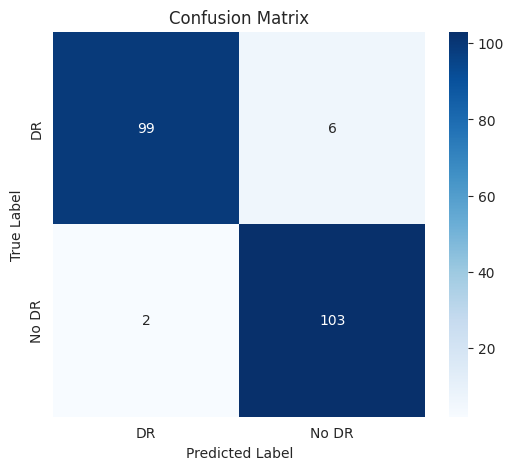

In [30]:
conf_matrix = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DR', 'No DR'], yticklabels=['DR', 'No DR'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, GaussianNoise, 
                                     Input, MultiHeadAttention, Reshape)
from tensorflow.keras.optimizers import Adam

def create_lightweight_model(input_shape):
    inputs = Input(shape=input_shape)
    base_model = MobileNetV2(weights='imagenet', input_tensor=inputs, include_top=False)
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    height, width, channels = x.shape[1], x.shape[2], x.shape[3]
    x = Reshape((height * width, channels))(x)
    attention_output = MultiHeadAttention(num_heads=4, key_dim=channels)(x, x)
    attention_output = Reshape((height, width, channels))(attention_output)
    x = GaussianNoise(0.2)(attention_output)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = GaussianNoise(0.2)(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (224, 224, 3)
cnn_model = create_lightweight_model(input_shape)
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [32]:
history = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=5,  
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
105/105 [==============================] - 6s 25ms/step - loss: 0.2148 - accuracy: 0.9262 - val_loss: 0.1179 - val_accuracy: 0.9619
Epoch 2/5
105/105 [==============================] - 2s 16ms/step - loss: 0.1301 - accuracy: 0.9589 - val_loss: 0.1100 - val_accuracy: 0.9667
Epoch 3/5
105/105 [==============================] - 2s 16ms/step - loss: 0.1002 - accuracy: 0.9667 - val_loss: 0.1440 - val_accuracy: 0.9381
Epoch 4/5
105/105 [==============================] - 2s 16ms/step - loss: 0.0904 - accuracy: 0.9708 - val_loss: 0.1078 - val_accuracy: 0.9714
Epoch 5/5
105/105 [==============================] - 2s 16ms/step - loss: 0.0648 - accuracy: 0.9815 - val_loss: 0.1245 - val_accuracy: 0.9714


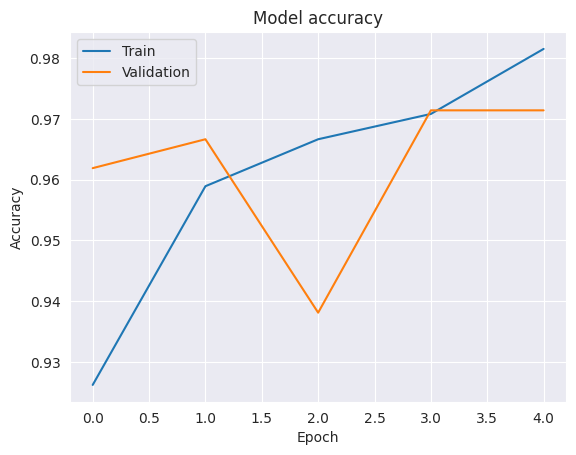

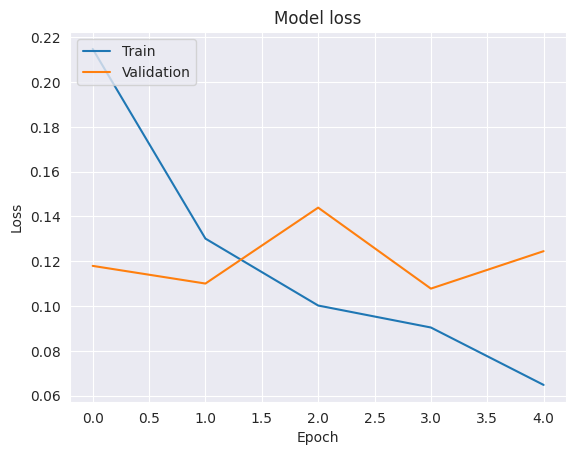

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [34]:
from sklearn.metrics import classification_report
test_labels = test_gen_new.classes  
predictions = cnn_model.predict(test_gen_new)  
predicted_labels = (predictions > 0.5).astype(int).flatten()
report = classification_report(test_labels, predicted_labels, target_names=list(test_gen_new.class_indices.keys()))
print(report)

14/14 [==============================] - 1s 11ms/step
              precision    recall  f1-score   support

           0       1.00      0.91      0.96       105
           1       0.92      1.00      0.96       105

    accuracy                           0.96       210
   macro avg       0.96      0.96      0.96       210
weighted avg       0.96      0.96      0.96       210



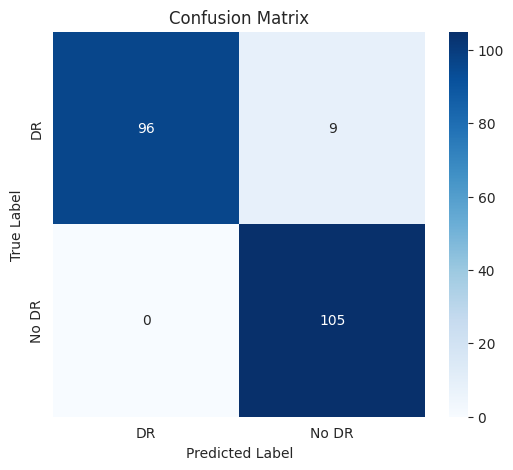

In [35]:
conf_matrix = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DR', 'No DR'], yticklabels=['DR', 'No DR'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [37]:
cnn_model.save("MobileNetV2-VGG16-DiabeticReti.h5")

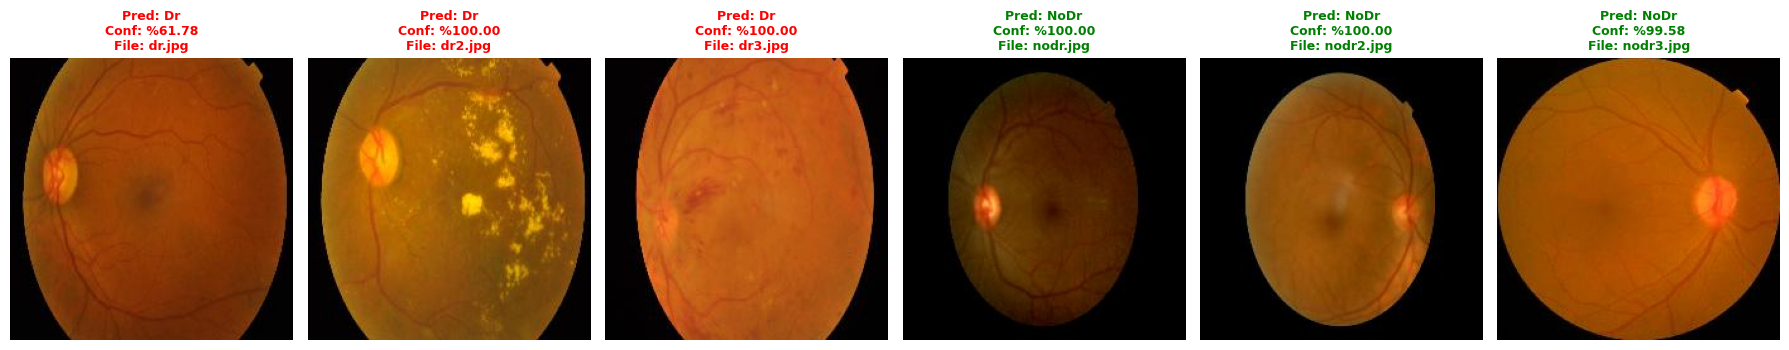

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# --- 1. AYARLAR ---
folder_path = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Diabetic Reti\TEST"
model_path = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Diabetic Reti\MobileNetV2-VGG16-DiabeticReti.h5"
model = tf.keras.models.load_model(model_path)

target_size = (224, 224)
class_labels = {0: 'Dr', 1: 'NoDr'} 

all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
selected_images = all_images[:6] 

# --- 2. TAHMİN VE GÖRSELLEŞTİRME ---
plt.figure(figsize=(18, 7))

for i, img_name in enumerate(selected_images):
    img_path = os.path.join(folder_path, img_name)
    
    # Görüntü hazırlama
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array / 255.0, axis=0)

    # Tahmin Mantığı
    preds = model.predict(img_batch, verbose=0)
    
    # Çıktı katmanı 1 nöron ise (Sigmoid)
    if preds.shape[1] == 1:
        prob = preds[0][0]
        # 0.5 eşik değerine göre sınıf belirleme
        class_idx = 1 if prob > 0.5 else 0
        confidence = prob * 100 if class_idx == 1 else (1 - prob) * 100
    # Çıktı katmanı 2 nöron ise (Softmax)
    else:
        class_idx = np.argmax(preds[0])
        confidence = preds[0][class_idx] * 100

    predicted_label = class_labels.get(class_idx, "Unknown")
    
    # Görselleştirme
    plt.subplot(1, 6, i + 1)
    plt.imshow(img_array.astype('uint8'))
    plt.axis('off')
    
    # Başlık rengini tahmine göre ayarla (Örn: Pneumonia ise Kırmızı, Normal ise Yeşil)
    title_color = 'red' if predicted_label == 'Dr' else 'green'
    
    plt.title(f"Pred: {predicted_label}\nConf: %{confidence:.2f}\nFile: {img_name}", 
              fontsize=9, color=title_color, fontweight='bold')

plt.tight_layout()
plt.show()

# Dr = 0 / No Dr = 1